# Jumia & Noon

## WebScraping

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, NoSuchElementException, WebDriverException
from bs4 import BeautifulSoup
import time
import re
import csv

def get_jumia_rating(product_url, driver):
    try:
        driver.get(product_url)
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "div.stars._m._al"))
        )
        rating_text = driver.find_element(By.CSS_SELECTOR, "div.stars._m._al").text
        rating = rating_text.split(' out of ')[0]
        return float(rating)
    except:
        return 0.0

def scrape_jumia_products(url, Department, website_name, max_pages=5):
    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--lang=ar")
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36")
    options.add_argument("accept-language=ar-EG,ar;q=0.9")
    options.add_experimental_option("excludeSwitches", ["enable-automation"])
    options.add_experimental_option("useAutomationExtension", False)
    
    driver = webdriver.Chrome(options=options)
    results = []
    
    try:
        for page in range(1, max_pages + 1):
            retry_count = 0
            max_retries = 3
            
            while retry_count < max_retries:
                try:
                    page_url = f"{url}&page={page}" if page > 1 else url
                    print(f"Attempting to scrape page {page} (attempt {retry_count + 1})...")
                    
                    driver.set_page_load_timeout(30)
                    try:
                        driver.get(page_url)
                    except WebDriverException:
                        print("Page load timed out, continuing anyway...")
                    
                    try:
                        WebDriverWait(driver, 15).until(
                            lambda d: d.find_elements(By.CSS_SELECTOR, "article.prd, article.c-prd, div.prd") or 
                                    "no results found" in d.page_source.lower()
                        )
                    except TimeoutException:
                        print("Timeout waiting for page content")
                        retry_count += 1
                        continue
                    
                    if "no results found" in driver.page_source.lower():
                        print("No products found - ending scraping")
                        return results
                    
                    # Scroll down to load more products
                    scroll_pause_time = 1
                    screen_height = driver.execute_script("return window.screen.height;")
                    scroll_step = screen_height // 3
                    
                    for i in range(3):
                        driver.execute_script(f"window.scrollTo(0, {scroll_step * (i + 1)});")
                        time.sleep(scroll_pause_time)
                    
                    soup = BeautifulSoup(driver.page_source, 'html.parser')
                    products = soup.find_all(['article', 'div'], class_=re.compile(r'prd|c-prd'))
                    
                    if not products:
                        print("No products found in page source")
                        retry_count += 1
                        continue
                    print(f"Found {len(products)} products on page {page}")
                    
                    for product in products:
                        try:
                           
                            name = product.find('h3', class_=re.compile('name|title'))
                            name = name.text.strip() if name else "N/A"
                            
                            
                            price = product.find('div', class_=re.compile('prc|price'))
                            price = price.text.strip() if price else "N/A"
                            
                            
                            old_price = product.find('div', class_=re.compile('old|original'))
                            old_price = old_price.text.strip() if old_price else "N/A"
                            
                            
                            discount = product.find('div', class_=re.compile('bdg.*dsct|discount'))
                            discount = discount.text.strip() if discount else "0%"
                            
                            
                            brand = "N/A"
                            link = product.find('a', class_=re.compile('core|link'))
                            if link:
                                brand = link.get('data-ga4-item_brand', 
                                               link.get('data-moengage-brand_name', 
                                               link.get('data-brand', "N/A")))
                            
                            product_link = None
                            if link and link.get('href'):
                                product_link = "https://www.jumia.com.eg" + link['href']
                            
                           
                            rating = 0.0
                            
                            results.append({
                                'Product Name': name,
                                'Price': price,
                                'Rating': 0.0,
                                'Best Seller': rating,
                                'Brand': brand,
                                'Discount': discount,
                                'Department': Department,
                                'website': website_name,
                                'Product URL': product_link
                            })
                            
                            
                        except Exception as e:
                            print(f"Error processing a product: {str(e)}")
                            continue
                    
                    break
                    
                except Exception as e:
                    print(f"Error processing page {page}: {str(e)}")
                    retry_count += 1
                    if retry_count >= max_retries:
                        print("Max retries reached for this page")
                        break
                    time.sleep(5)
            
            time.sleep(3)
            
    except Exception as e:
        print(f"Fatal error in scraper: {str(e)}")
    finally:
        driver.quit()
    
    return results

def scrape_noon_products(url, Department, website_name):
    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument("--lang=ar")
    options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36")
    options.add_argument("accept-language=ar-EG,ar;q=0.9")
    
    driver = webdriver.Chrome(options=options)
    results = []
    
    try:
        for i in range(1, 5):  
            try:
                driver.get(url + f"&page={i}")
                WebDriverWait(driver, 20).until(
                    EC.presence_of_element_located((By.CSS_SELECTOR, ".ProductBoxVertical_wrapper__xPj_f"))
                )
                
                
                soup = BeautifulSoup(driver.page_source, 'html.parser', from_encoding='utf-8')
                products = soup.find_all('div', class_='ProductBoxVertical_wrapper__xPj_f')
                
                for product in products:
                    try:
                        name = product.find('h2', {'data-qa': 'product-name'}).get('title', '').strip()
                        price_currency = product.find('span', class_='Price_currency__taKQj').text.strip()
                        price_amount = product.find('strong', class_='Price_amount__2sXa7').text.strip()
                        price = f"{price_currency} {price_amount}"
                        
                        rating_element = product.find('div', class_='RatingPreviewStar_textCtr__sfsJG')
                        rating = float(rating_element.text.strip()) if rating_element else 0.0

                        best_seller = "Yes" if product.find('div', class_='BestSellerTag_container__q2YWE') else "No"
                        brand = name.split()[0] if name else "N/A"
                        
                        discount_element = product.find('span', class_='PriceDiscount_discount__1ViHb')
                        discount_text = discount_element.text.strip() if discount_element else "0%"
                        discount = re.search(r'(\d+%)', discount_text).group(1) 

                        results.append({
                            'Product Name': name,
                            'Price': price,
                            'Rating': rating,
                            'Best Seller': best_seller,
                            'Brand': brand,
                            'Discount': discount,
                            'Department': Department,
                            'website': website_name
                        })
                        
                    except Exception as e:
                        print(f"Error processing product: {str(e)}")
                        continue
                    
            except Exception as e:
                print(f"Error in page {i}: {str(e)}")
                continue
                
            time.sleep(3) 
        
        return results
    
    finally:
      driver.quit()
      
      
url_List_noon = { "Shose":"https://www.noon.com/egypt-en/search/?q=shose",
            "Womens jewellery":"https://www.noon.com/egypt-en/fashion/women-31229/womens-jewellery/?",
            "Clothes":  "https://www.noon.com/egypt-en/search/?q=clothes",
            "Laptops":"https://www.noon.com/egypt-en/search/?q=laptop",
            "Books":"https://www.noon.com/egypt-en/search/?q=books"
            
}

url_List_jumia = { "Shose":"https://www.jumia.com.eg/catalog/?q=shoes+for+men",
            "Womens jewellery":"https://www.jumia.com.eg/catalog/?q=Womens+jewellery",
            "Clothes":  "https://www.jumia.com.eg/catalog/?q=Clothes",
            "Laptops":"https://www.jumia.com.eg/catalog/?q=Laptops",
            "Books":"https://www.jumia.com.eg/catalog/?q=Books"
            }

results = []


for category, url in url_List_jumia.items():
    print(f"Scraping URL: {url}")
    products = scrape_jumia_products(url, category, "Jumia")
    
 
    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    driver = webdriver.Chrome(options=options)
    
    try:
        for product in products:
            if product["Product URL"]:
                rating = get_jumia_rating(product.pop("Product URL"), driver)
                product["Rating"] = rating
                time.sleep(2)  
    finally:
        driver.quit()
        
    results.extend(products)


for category, url in url_List_noon.items():
    print(f"Scraping URL: {url}")
    products = scrape_noon_products(url, category, "Noon")
    results.extend(products)

# Export to CSV
with open('All_products2.csv', 'w', newline='', encoding='utf-8-sig') as csvfile:
    fieldnames = ['Product Name', 'Price', 'Rating','Best Seller', 
                'Brand', 'Discount', 'Department','website']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)  

In [16]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
# from pymongo import MongoClient



In [2]:
df = pd.read_csv('All_products2.csv')
df.head()

,Product Name,Price,Rating,Best Seller,Brand,Discount,Department,website
0,Decathlon Men's Running Shoes Jogflow 100.1 Bl...,"EGP 1,799.00",4.4,0.0,Decathlon,0%,Shose,Jumia
1,Decathlon Men's Running Shoes Jogflow 100.1 Bl...,"EGP 1,799.00",4.6,0.0,Decathlon,0%,Shose,Jumia
2,Decathlon Agility 100 HG Adult Firm Pitch Foot...,"EGP 1,799.00",4.2,0.0,Decathlon,0%,Shose,Jumia
3,Decathlon RUN ACTIVE GRIP MEN'S RUNNING SHOES ...,"EGP 2,899.00",4.2,0.0,Decathlon,0%,Shose,Jumia
4,Decathlon Run Active Men's Running Shoes - Khaki,"EGP 2,899.00",4.4,0.0,Decathlon,0%,Shose,Jumia


## Cleaning section


In [5]:
def clean_price(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, float)):
        return value 
    match = re.search(r'\d+(\.\d+)?', str(value).replace(',', ''))
    return float(match.group()) if match else None

In [6]:
df['Price'] = df['Price'].apply(clean_price)

In [7]:
df['Discount'] = df['Discount'].apply(lambda x: float(re.sub(r'[^\d.]', '', str(x))) if pd.notna(x) else 0.0)

In [8]:
df["Price_After_Discount"] = df["Price"] * (1 - df["Discount"] / 100)

In [9]:
df.duplicated().sum()

np.int64(227)

In [10]:
df.drop_duplicates(inplace=True)
df.reset_index(inplace = True)
df.drop(columns = 'index' , inplace = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1837 entries, 0 to 1836
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product Name          1837 non-null   object 
 1   Price                 1837 non-null   float64
 2   Rating                1837 non-null   float64
 3   Best Seller           1837 non-null   object 
 4   Brand                 1837 non-null   object 
 5   Discount              1837 non-null   float64
 6   Department            1837 non-null   object 
 7   website               1837 non-null   object 
 8   Price_After_Discount  1837 non-null   float64
dtypes: float64(4), object(5)
memory usage: 129.3+ KB


In [13]:
df.describe()

,Price,Rating,Discount,Price_After_Discount
count,1837.000000,1837.000000,1837.000000,1837.000000
mean,8094.088955,2.437725,22.364181,7121.810456
std,17673.676959,2.216928,21.081300,15981.918101
min,9.990000,0.000000,0.000000,1.521000
25%,195.000000,0.000000,0.000000,138.720000
50%,425.000000,3.600000,20.000000,295.000000
75%,2760.000000,4.500000,37.000000,1824.500000
max,219499.000000,5.000000,87.000000,219499.000000


### removing outlires

In [14]:
df_by_web = df.groupby("website")
df_noon = df_by_web.get_group("Noon").groupby("Department")
df_jumia = df_by_web.get_group("Jumia").groupby("Department")


In [17]:
groupsn =[]
for i , group in df_noon:
    group["Z_Score"] = np.abs(zscore(group["Price"]))
    group = group[group["Z_Score"] < 2.5]
    group = group.drop(columns=["Z_Score"])
    groupsn.append(group)
df_noon_cleaned = pd.concat(groupsn, ignore_index=True)

groupsj =[]
for i , group in df_jumia:
    group["Z_Score"] = np.abs(zscore(group["Price"]))
    group = group[group["Z_Score"] < 2.5]
    group = group.drop(columns=["Z_Score"])
    groupsj.append(group)

df_jumia_cleaned = pd.concat(groupsj, ignore_index=True)

df_cleaned = pd.concat([ df_jumia_cleaned , df_noon_cleaned ], ignore_index=True)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1790 entries, 0 to 1789
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product Name          1790 non-null   object 
 1   Price                 1790 non-null   float64
 2   Rating                1790 non-null   float64
 3   Best Seller           1790 non-null   object 
 4   Brand                 1790 non-null   object 
 5   Discount              1790 non-null   float64
 6   Department            1790 non-null   object 
 7   website               1790 non-null   object 
 8   Price_After_Discount  1790 non-null   float64
dtypes: float64(4), object(5)
memory usage: 126.0+ KB


# Anylsis section

In [18]:
df_cleaned.describe()

,Price,Rating,Discount,Price_After_Discount
count,1790.000000,1790.000000,1790.000000,1790.000000
mean,7721.254419,2.445866,22.744134,6791.568323
std,16205.562168,2.214297,21.101167,14613.443805
min,9.990000,0.000000,0.000000,1.521000
25%,189.000000,0.000000,0.000000,133.330000
50%,405.000000,3.600000,20.000000,280.250000
75%,2462.750000,4.500000,38.000000,1688.625000
max,97328.000000,5.000000,87.000000,93999.000000


## Prices comparison

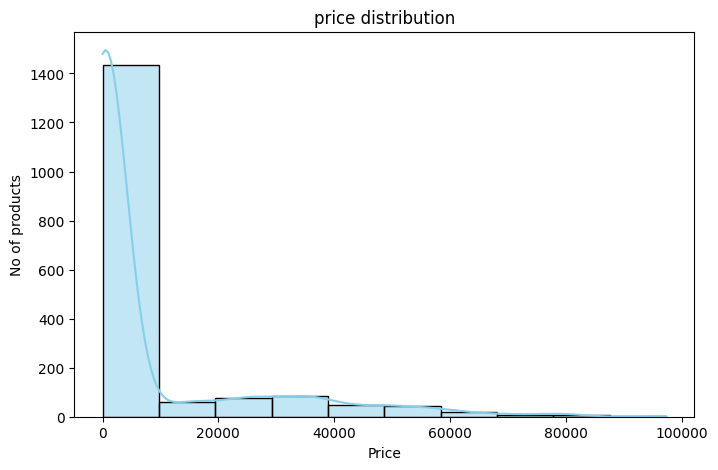

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned["Price"], bins=10, kde=True, color="skyblue")
plt.title("price distribution")
plt.xlabel("Price")
plt.ylabel("No of products")
plt.show()


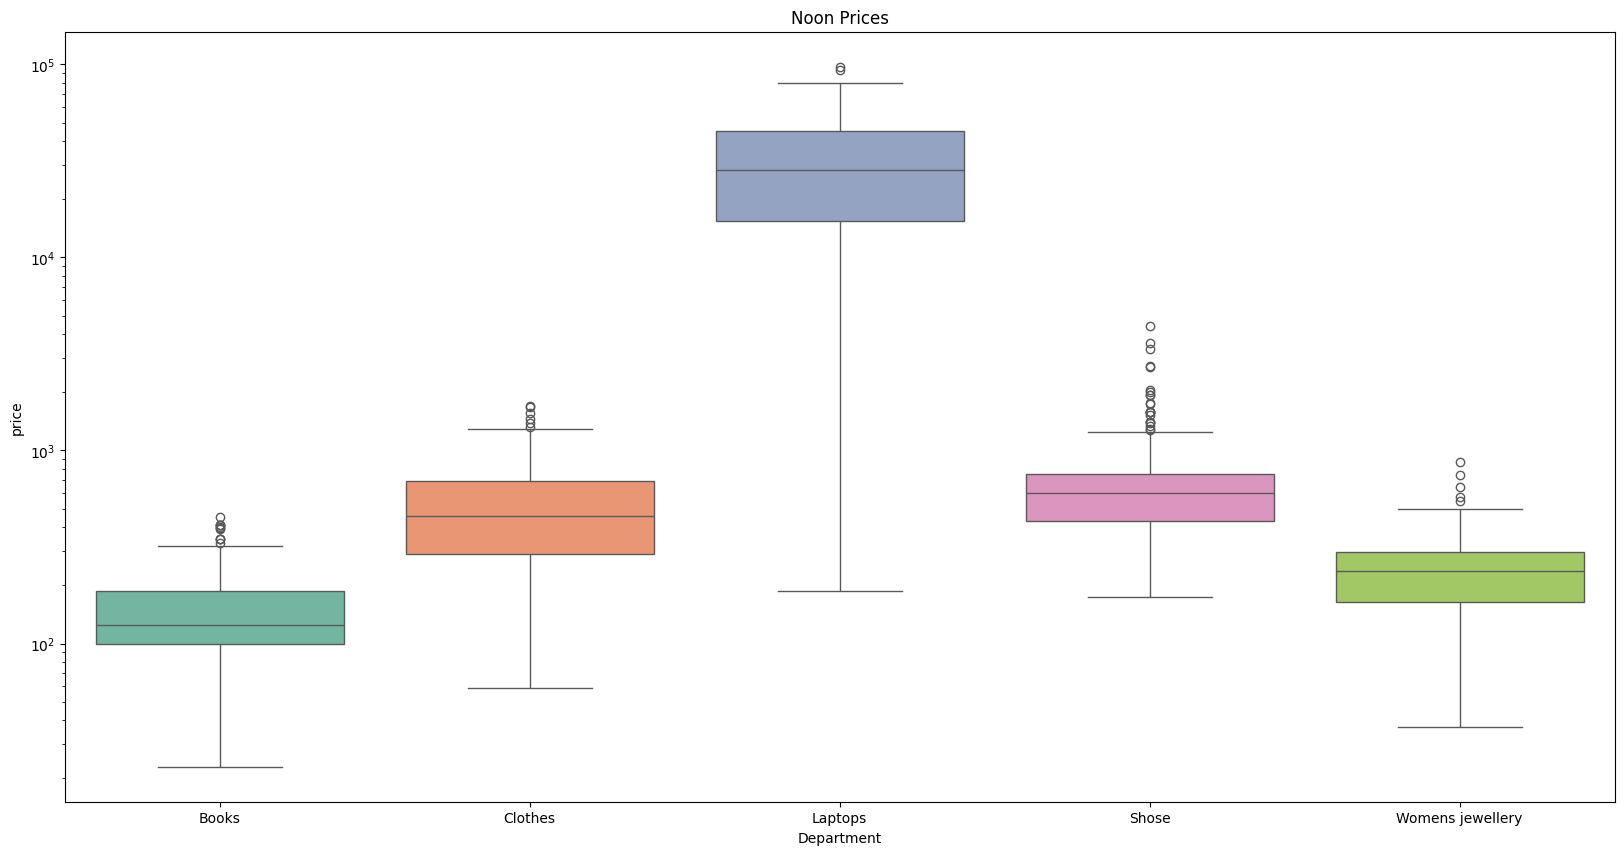

In [20]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_noon_cleaned, x="Department", y="Price", hue="Department", palette="Set2", legend=False)
plt.yscale("log")  
plt.title("Noon Prices")
plt.xlabel("Department")
plt.ylabel("price")
plt.show()


In [21]:
df_noon_cleaned.groupby("Department").agg({
    "Price": ["mean", "max", "min"]
    
})

Price                
                          mean      max    min
Department                                    
Books               153.521316    450.0   23.0
Clothes             520.531421   1699.0   59.0
Laptops           31184.718919  97328.0  188.0
Shose               764.120231   4399.0  175.0
Womens jewellery    252.925000    875.0   37.0

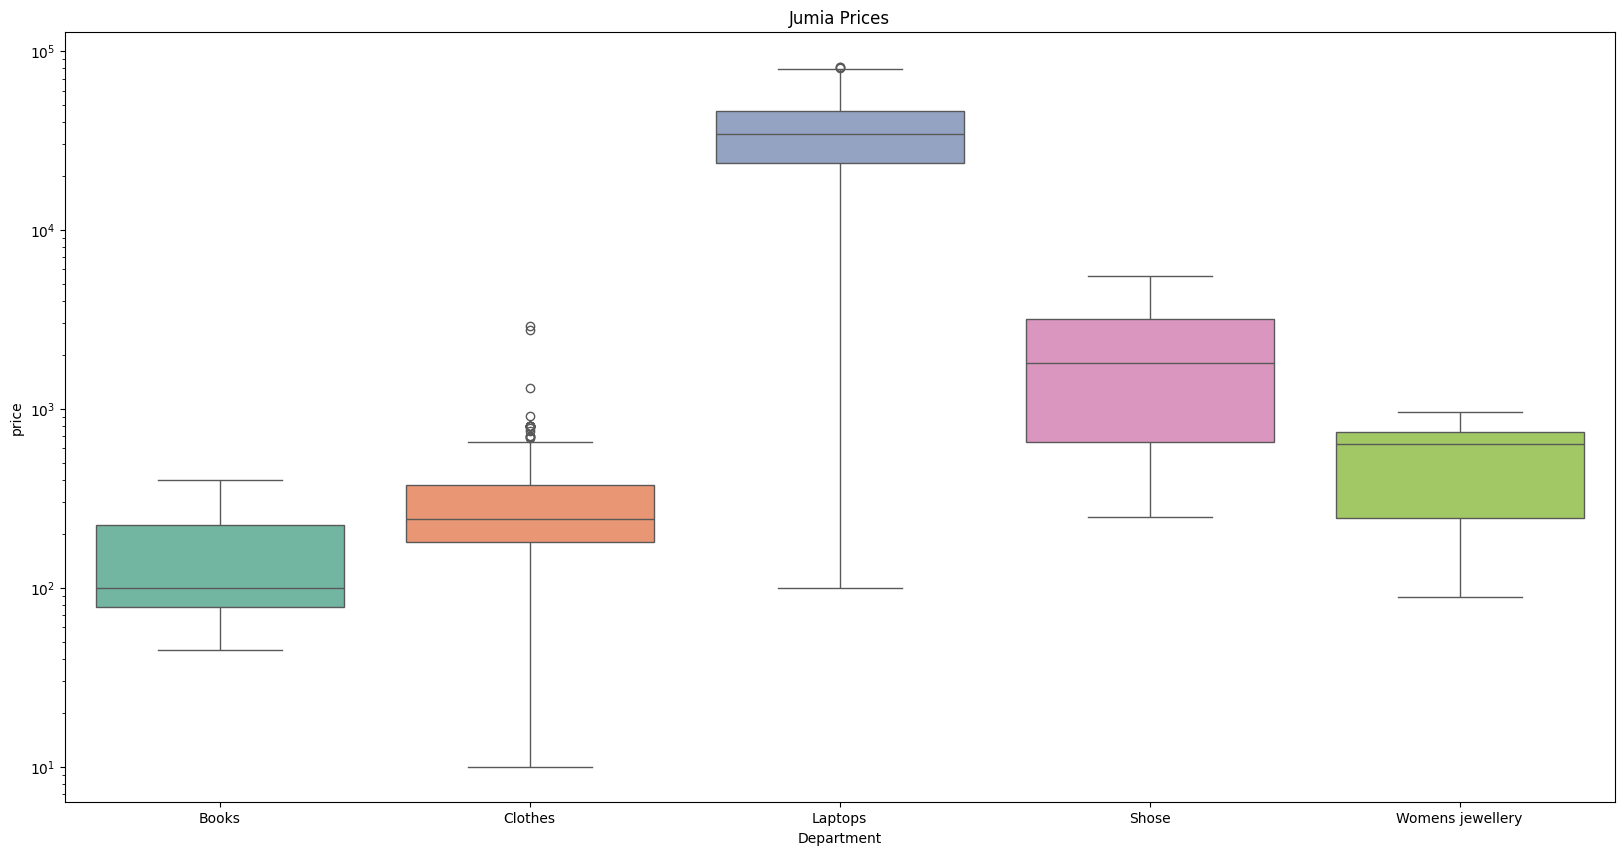

In [22]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df_jumia_cleaned, x="Department", y="Price", hue="Department", palette="Set2", legend=False)
plt.yscale("log")  
plt.title("Jumia Prices")
plt.xlabel("Department")
plt.ylabel("price")
plt.show()

In [23]:
df_jumia_cleaned.groupby("Department").agg({
    "Price": ["mean", "max", "min"]
    
})

Price                 
                          mean      max     min
Department                                     
Books               148.654255    399.0   45.00
Clothes             316.102892   2900.0    9.99
Laptops           36088.829146  81499.0  100.00
Shose              2040.346109   5499.0  249.00
Womens jewellery    525.833333    958.0   89.00

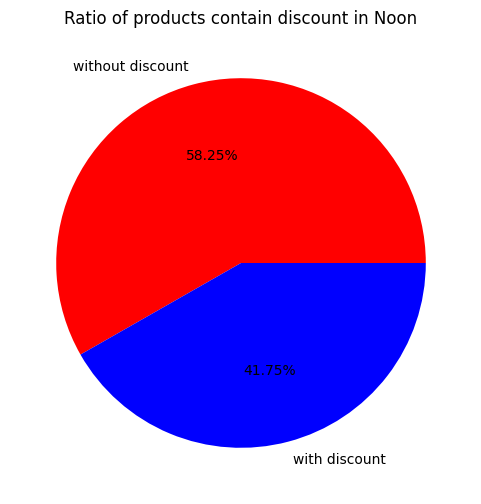

In [24]:
has_discount = (df_noon_cleaned["Discount"] > 0).sum()
no_discount = (df_noon_cleaned["Discount"] == 0).sum()

plt.figure(figsize=(6, 6))
plt.pie([has_discount, no_discount], labels=["without discount","with discount"], autopct='%1.2f%%', colors=["r", "b"])
plt.title("Ratio of products contain discount in Noon")
plt.show()


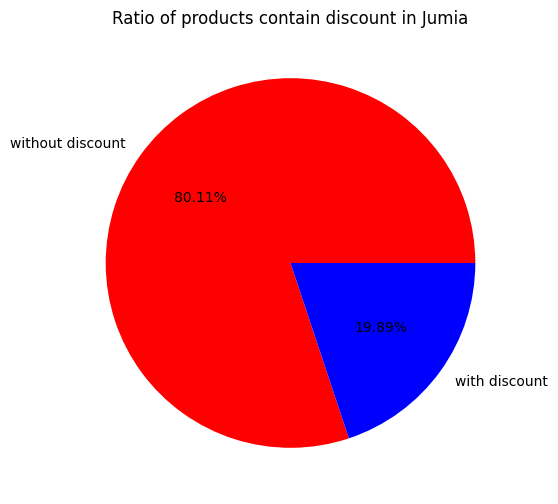

In [25]:
has_discount = (df_jumia_cleaned["Discount"] > 0).sum()
no_discount = (df_jumia_cleaned["Discount"] == 0).sum()

plt.figure(figsize=(6, 6))
plt.pie([has_discount, no_discount], labels=["without discount","with discount"], autopct='%1.2f%%', colors=["r", "b"])
plt.title("Ratio of products contain discount in Jumia")
plt.show()


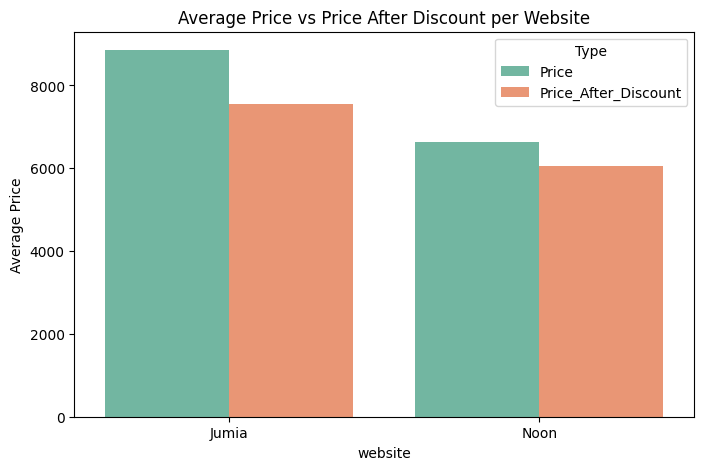

In [26]:
avg_prices = df_cleaned.groupby("website")[["Price", "Price_After_Discount"]].mean().reset_index()

plt.figure(figsize=(8,5))
avg_prices_melted = avg_prices.melt(id_vars="website", var_name="Type", value_name="Average Price")

sns.barplot(data=avg_prices_melted, x="website", y="Average Price", hue="Type", palette="Set2")
plt.title("Average Price vs Price After Discount per Website")
plt.show()


## Best Brands

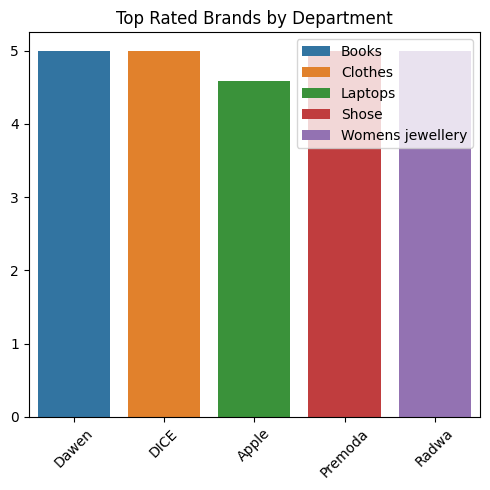

In [27]:
top_brands =[]
top_rating = []
hue = []
for i , group in df_noon_cleaned.groupby("Department"):
    t = group.groupby("Brand")["Rating"].mean()
    top_brand = t.idxmax() 
    rating = t.max() 
    hue.append(str(i))
    top_brands.append(top_brand)
    top_rating.append(rating)
    
 


plt.figure(figsize=(5, 5))
sns.barplot( x=top_brands, y=top_rating , hue = hue)
plt.title("Top Rated Brands by Department")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

Books
Clothes
Laptops
Shose
Womens jewellery
['edu tec', 'Junior', 'Generic', 'Umbro', 'Generic']


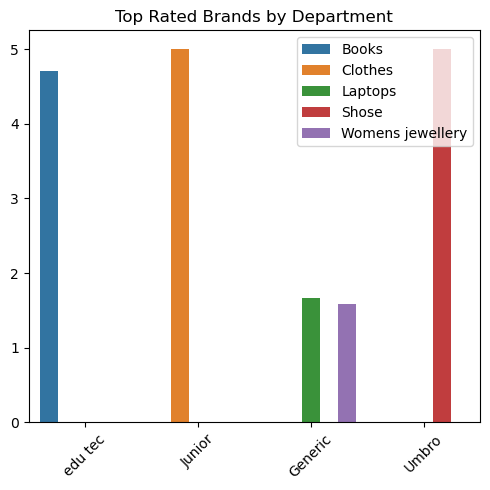

In [83]:
top_brands =[]
top_rating = []
hue = []
for i , group in df_jumia_cleaned.groupby("Department"):
    print(i)
    t = group.groupby("Brand")["Rating"].mean()
    top_brand = t.idxmax() 
    rating = t.max() 
    hue.append(str(i))
    top_brands.append(top_brand)
    top_rating.append(rating)
    
 

print(top_brands)
plt.figure(figsize=(5, 5))
sns.barplot( x=top_brands, y=top_rating , hue = hue)
plt.title("Top Rated Brands by Department")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

## Top Product For Each Brand

In [52]:

for i , group in df_noon_cleaned.groupby("Brand"):
    t = group[["Rating" , "Product Name"]].max()
    if t["Rating"] > 0 :
        print( str(i) +"-"*10 + t["Product Name"] + "-"*5 + str(t["Rating"]))
    



A----------A moral in their stories-----3.7
ANTA----------ANTA Outdoor Shoes Anti-Slip Grip Shoes-----5.0
ARTLOOK----------ARTLOOK kids autumn outfit-----3.2
ASTK----------ASTK SLIM FIT JERSAY-----5.0
ASUS----------ASUS Zenbook Duo Laptop With 14-Inch Display, Core U7-155H Processor/16GB RAM/1TB SSD/Windows 11 English/Arabic Inkwell Gray-----5.0
Ababil----------Ababil Arabic By Ahmed Al Hamdan Arabic by Ahmed al Hamdan-----4.3
Activ----------Activ Fashion Shoes-----5.0
Adidas----------Adidas Ozelle Cloudfoam Lifestyle Running Shoes-----4.7
Akher----------Akher el Ankoud Silver Stainless Steel Ring-----5.0
Al-Tantouriya----------Al-Tantouriya-----4.5
Amarita----------Amarita ( Land of zicola 2 )-----4.2
Antichristos----------Antichristos Part One-----2.4
Apple----------Apple New 2025 MacBook Air MW123 13-Inch Display, Apple M4 Chip 10-Core CPU 8-Core GPU Processor/16GB RAM/256GB SSD/macOS(International Version) English Midnight-----4.8
Asrar----------Asrar Akl Millionaire Secrets - Pape

In [54]:

for i , group in df_jumia_cleaned.groupby("Brand"):
    t = group[["Rating" , "Product Name"]].max()
    if t["Rating"] > 0 :
        print( str(i) +"-"*10 + t["Product Name"] + "-"*5 + str(t["Rating"]))
    

ADIDAS----------ADIDAS Women • Sportswear Edge Lux Shoes  Gz6738-----5.0
AM-Shop----------AM-Shop Set Of (12) Socks - For Kids – Color May Vary-----3.6
Acer----------Acer TravelMate P614 - I7 - 1355U 16GB 1TB SSD 14"WUXGA-----5.0
Air Walk----------Air Walk Round Toecap Multi Pattern Hockey Shoes - Yellow & Black-----3.5
Andora----------Andora Zipper Pockets Practical Plain Boys Shorts - Black-----5.0
Anta----------Anta X-Game Shoes For Men - White/Green-----5.0
Asus----------Asus Zenbook S 13 OLED UX5304VA-OLED517W - 13.3-inch Intel® Core™ i7-1355U 16GB 512GB-SSD Intel Iris Xᵉ - Basalt Grey-----5.0
Blue Bird----------Blue Bird Sport Shoes B7t Boots Football Tartan Silver-----4.2
Blue Brid----------Blue Brid Sports Shoes SE Synthetic Turf-----4.5
Book Store----------Book Store ﺃننى ﺃتعفن رعبا-----5.0
Caesar----------Caesar Women Pajama Set With Pants And Button Design-----4.7
Carina----------Carina (Cookies) Slim Fit Cotton Hot Short-----5.0
Cottonil----------Cottonil Bundle OF (5) - Me

## Best Department for each website

In [57]:
temp = 0 
res = []
for i , group in df_noon_cleaned.groupby("Department"):
    t = group["Rating"].mean()
    if t > temp :
        temp = t
        res  = [t ,i ]
        
print(f"The Best Dep in Noon is { res[1] } with mean rating { res[0] } ")   

The Best Dep in Noon is Books with mean rating 3.568421052631579 


In [59]:
temp = 0 
res = []
for i , group in df_jumia_cleaned.groupby("Department"):
    t = group["Rating"].mean()
    if t > temp :
        temp = t
        res  = [t ,i ]
        
print(f"The Best Dep in Jumia is { res[1] } with mean rating { res[0] } ")

The Best Dep in Jumia is Clothes with mean rating 3.6566265060240966 


##  Multivariate Analysis

<Axes: >

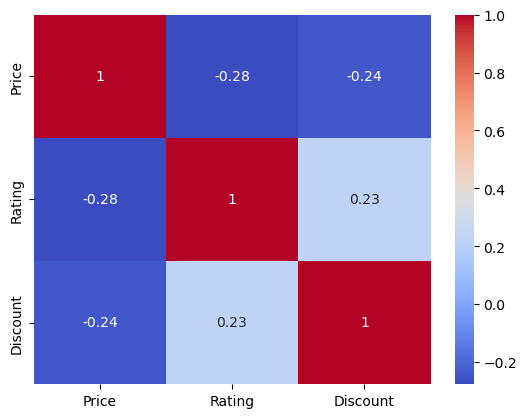

In [62]:
corr = df_cleaned[["Price" , "Rating" , "Discount"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

# RandomForestRegressor

In [152]:
print(df_cleaned["Department"].unique())
print(df_cleaned["website"].unique())


['Books' 'Clothes' 'Laptops' 'Shose' 'Womens jewellery']
['Jumia' 'Noon']


      Rating  Discount  Price  Brand  website
0        3.0      25.0  225.0     88        0
1        5.0       9.0   98.0     88        0
2        1.0      70.0   75.0     88        0
3        0.0       7.0  100.0     88        0
4        0.0       7.0  100.0     88        0
...      ...       ...    ...    ...      ...
1785     0.0       0.0  295.0    133        1
1786     0.0       0.0  220.0    133        1
1787     0.0       0.0  295.0    133        1
1788     0.0       0.0  249.0    194        1
1789     0.0       0.0  750.0    110        1

[1790 rows x 5 columns]


C:\Users\SH\AppData\Local\Temp\ipykernel_19064\3867447307.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lab_df["Brand"] = encoder.fit_transform(lab_df["Brand"])
C:\Users\SH\AppData\Local\Temp\ipykernel_19064\3867447307.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lab_df["website"] = encoder.fit_transform(lab_df["website"])


<Axes: >

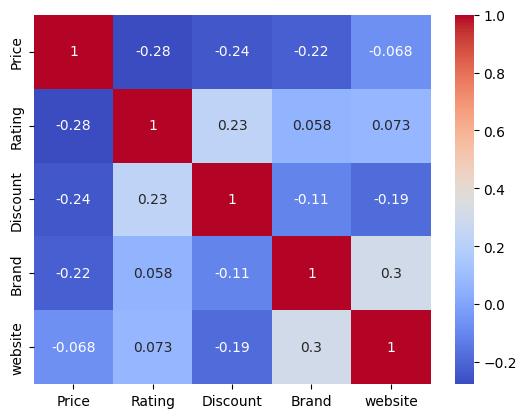

In [148]:
from sklearn.preprocessing import LabelEncoder
lab_df = df_cleaned#[df_cleaned["Department"] == 'Shose']
lab_df = lab_df[["Rating", "Discount", "Price","Brand","website"]]
# Fit and transform
encoder = LabelEncoder()
lab_df["Brand"] = encoder.fit_transform(lab_df["Brand"])
lab_df["website"] = encoder.fit_transform(lab_df["website"])

print(lab_df)
corr = lab_df[["Price" , "Rating" , "Discount", "Brand", "website"]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [149]:

Q1 = lab_df.quantile(0.25)
Q3 = lab_df.quantile(0.75)
IQR = Q3 - Q1

lab_df = lab_df[~((lab_df < (Q1 - 1.5 * IQR)) | (lab_df> (Q3 + 1.5 * IQR))).any(axis=1)]
print(lab_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1372 entries, 0 to 1789
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Rating    1372 non-null   float64
 1   Discount  1372 non-null   float64
 2   Price     1372 non-null   float64
 3   Brand     1372 non-null   int64  
 4   website   1372 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 64.3 KB
None


In [150]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler

x= lab_df.drop(columns=["Price"])
y= lab_df["Price"]

scaler = StandardScaler()
data_standardized = scaler.fit_transform(lab_df.drop(columns=["Price"]))
x_train, x_test, y_train, y_test = train_test_split(data_standardized, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Squared Error: 196658.7415269104
R² Score: 0.802118190605753


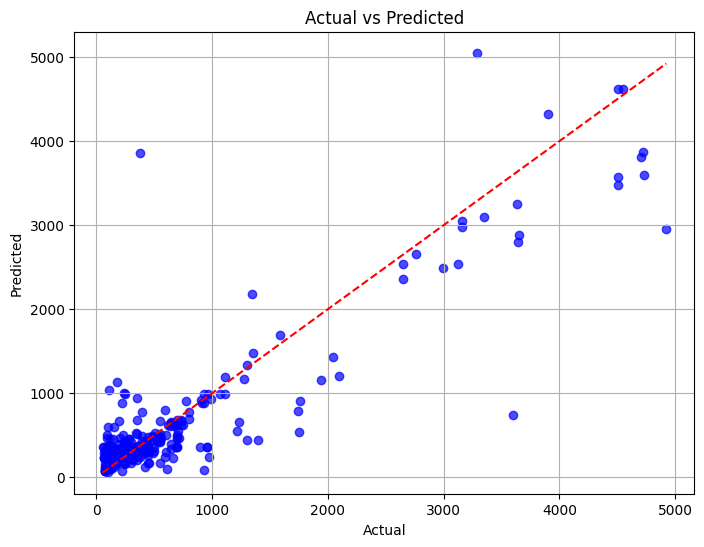

In [151]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()


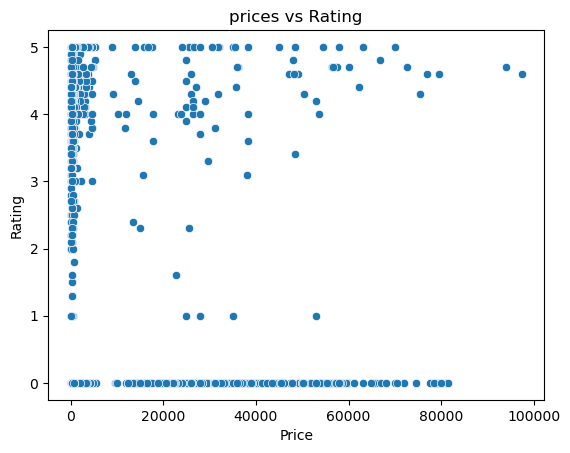

In [64]:
sns.scatterplot(x='Price', y='Rating', data=df_cleaned)
plt.title('prices vs Rating')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.show()

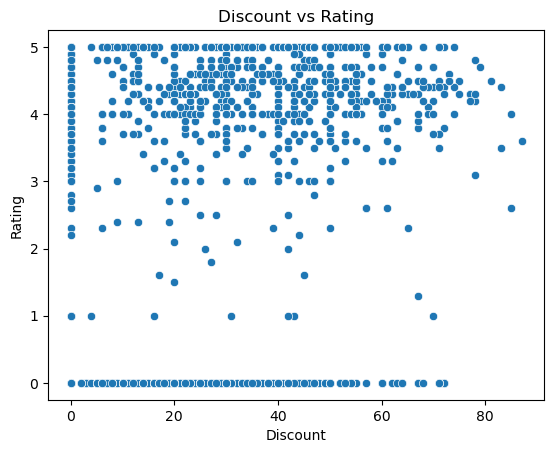

In [66]:
sns.scatterplot(x='Discount', y='Rating', data=df_cleaned)
plt.title('Discount vs Rating')
plt.xlabel('Discount')
plt.ylabel('Rating')
plt.show()

In [69]:
client = MongoClient("mongodb://localhost:27017/")


In [71]:
db = client["products_db"]       
collection = db["products"] 

In [73]:
data_dict = df_cleaned.to_dict("records")


In [75]:
collection.insert_many(data_dict)
print(" Data has been successfully inserted into MongoDB!")


 Data has been successfully inserted into MongoDB!


In [77]:
data_from_mongo = list(collection.find())


In [79]:
for item in data_from_mongo:
    item.pop("_id", None)


In [81]:
import json

with open("mongo_data.json", "w", encoding="utf-8") as f:
    json.dump(data_from_mongo, f, indent=4, ensure_ascii=False)
print(" Data has been successfully inserted into MongoDB!")



 Data has been successfully inserted into MongoDB!


# streamlit

In [ ]:
import streamlit as st
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
# from pymongo import MongoClient
from scipy.stats import zscore
import numpy as np
import time

# def init_connection():
#     return MongoClient("mongodb://localhost:27017")  # Change to your DB URI if needed

# client = init_connection()
# db = client["product_db"]
# collection = db["products"]




if 'df_cleaned' not in st.session_state:
    st.session_state.df_cleaned = None
    st.session_state.show_analysis = False
def clean_price(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, float)):
        return value
    match = re.search(r'\d+(\.\d+)?', str(value).replace(',', ''))
    return float(match.group()) if match else None



st.title("E commerce Anylsis 🛍️")

uploaded_file = st.file_uploader("Upload your CSV file", type="csv")

if uploaded_file:
    df = pd.read_csv(uploaded_file)
    st.session_state.df = df
    st.subheader("Orignal Data 📄")
    st.write(df.head())
    st.session_state.data_uploaded = True


if st.session_state.get("data_uploaded", False):
    st.subheader("Cleaning lab 🧹")
    if st.button("Clean Data"):

        df['Price'] = df['Price'].apply(clean_price)
        df['Discount'] = df['Discount'].apply(lambda x: float(re.sub(r'[^\d.]', '', str(x))) if pd.notna(x) else 0.0)
        df["Price_After_Discount"] = df["Price"] * (1 - df["Discount"] / 100)
        df.drop_duplicates(inplace=True)
        df.reset_index(inplace=True)
        df.drop(columns='index', inplace=True)


        df_by_web = df.groupby("website")
        df_noon = df_by_web.get_group("Noon").groupby("Department")
        df_jumia = df_by_web.get_group("Jumia").groupby("Department")

        groupsn = []
        for i, group in df_noon:
            group["Z_Score"] = np.abs(zscore(group["Price"]))
            group = group[group["Z_Score"] < 2.5]
            group = group.drop(columns=["Z_Score"])
            groupsn.append(group)
        df_noon_cleaned = pd.concat(groupsn, ignore_index=True)

        groupsj = []
        for i, group in df_jumia:
            group["Z_Score"] = np.abs(zscore(group["Price"]))
            group = group[group["Z_Score"] < 2.5]
            group = group.drop(columns=["Z_Score"])
            groupsj.append(group)

        df_jumia_cleaned = pd.concat(groupsj, ignore_index=True)
        df_cleaned = pd.concat([df_jumia_cleaned, df_noon_cleaned], ignore_index=True)


        st.write(df_cleaned.head())
        st.session_state.df_cleaned = df_cleaned
        st.session_state.df_jumia_cleaned = df_jumia_cleaned
        st.session_state.df_noon_cleaned = df_noon_cleaned


        st.session_state.show_cleaning = True
        st.success("Done!")
        st.session_state.show_analysis = True
if st.session_state.show_analysis:
    st.subheader("Analysis Section 📊")

    if st.button("Description of The Data"):
        st.dataframe(st.session_state.df_cleaned.describe())


    if st.button("Prices Anylsis"):

        st.markdown("<h4 style='color: #dceae8;'>Price Distribution </h4>", unsafe_allow_html=True)
        fig = plt.figure(figsize=(8, 5))
        sns.histplot(st.session_state.df_cleaned["Price"], bins=10, kde=True, color="skyblue")
        plt.title("Price Distribution")
        plt.xlabel("Price")
        plt.ylabel("No. of Products")

        st.pyplot(fig)
        st.markdown("<h4 style='color: yellow;'>Noon Prices Distributions </h4>", unsafe_allow_html=True)
        fig1 = plt.figure(figsize=(10, 8))
        sns.boxplot(data=st.session_state.df_noon_cleaned, x="Department", y="Price", hue="Department", palette="Set2", legend=False)
        plt.yscale("log")
        plt.title("Noon Prices")
        plt.xlabel("Department")
        plt.ylabel("price")
        st.pyplot(fig1)

        has_discount = (st.session_state.df_noon_cleaned["Discount"] > 0).sum()
        no_discount = (st.session_state.df_noon_cleaned["Discount"] == 0).sum()
        fig2 = plt.figure(figsize=(3, 3))
        plt.pie([has_discount, no_discount], labels=["without discount", "with discount"], autopct='%1.2f%%',
                colors=["r", "b"])
        plt.title("Ratio of products contain discount in Noon")
        st.pyplot(fig2)
        st.write(st.session_state.df_noon_cleaned.groupby("Department").agg({"Price": ["mean", "max", "min"]}))

        ################################################################
        st.markdown("<h4 style='color: orange;'>Jumia Prices Distributions </h4>", unsafe_allow_html=True)
        fig3 = plt.figure(figsize=(10, 8))
        sns.boxplot(data=st.session_state.df_jumia_cleaned, x="Department", y="Price", hue="Department", palette="Set2",
                    legend=False)
        plt.yscale("log")
        plt.title("jumia Prices")
        plt.xlabel("Department")
        plt.ylabel("price")
        st.pyplot(fig3)

        has_discount = (st.session_state.df_jumia_cleaned["Discount"] > 0).sum()
        no_discount = (st.session_state.df_jumia_cleaned["Discount"] == 0).sum()

        fig4 =plt.figure(figsize=(3, 3))
        plt.pie([has_discount, no_discount], labels=["without discount", "with discount"], autopct='%1.2f%%',
                colors=["r", "b"])
        plt.title("Ratio of products contain discount in Jumia")
        st.pyplot(fig4)

        st.write(st.session_state.df_jumia_cleaned.groupby("Department").agg({"Price": ["mean", "max", "min"]}))


    if st.button("Best Brands"):
        st.markdown("<h4 style='color: yellow;'>Noon Top Brands </h4>", unsafe_allow_html=True)

        top_brands = []
        top_rating = []
        hue = []
        for i, group in st.session_state.df_noon_cleaned.groupby("Department"):
            t = group.groupby("Brand")["Rating"].mean()
            top_brand = t.idxmax()
            rating = t.max()
            hue.append(str(i))
            top_brands.append(top_brand)
            top_rating.append(rating)

        fig5 = plt.figure(figsize=(8, 5))
        sns.barplot(x=top_brands, y=top_rating, hue=hue)
        plt.title("Top Rated Brands by Department")
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()

        st.pyplot(fig5)

        st.markdown("<h4 style='color: orange;'>Jumia Top Brands </h4>", unsafe_allow_html=True)

        top_brands = []
        top_rating = []
        hue = []
        for i, group in st.session_state.df_jumia_cleaned.groupby("Department"):
            t = group.groupby("Brand")["Rating"].mean()
            top_brand = t.idxmax()
            rating = t.max()
            hue.append(str(i))
            top_brands.append(top_brand)
            top_rating.append(rating)

        fig6 = plt.figure(figsize=(8, 5))
        sns.barplot(x=top_brands, y=top_rating, hue=hue)
        plt.title("Top Rated Brands by Department")
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()

        st.pyplot(fig6)

    if st.button("Best Department for each website"):
        st.markdown("<h4 style='color: yellow;'>Noon </h4>", unsafe_allow_html=True)
        temp = 0
        res = []
        for i, group in st.session_state.df_noon_cleaned.groupby("Department"):
            t = group["Rating"].mean()
            if t > temp:
                temp = t
                res = [t, i]
        string1 = f"The Best Dep in Noon is {res[1]} with mean rating =  {res[0]} "
        st.markdown(f"<h5 style='color: white;'>{string1}</h4>", unsafe_allow_html=True)
        st.markdown("<h4 style='color: orange;'>Jumia </h4>", unsafe_allow_html=True)
        temp = 0
        res = []
        for i, group in st.session_state.df_jumia_cleaned.groupby("Department"):
            t = group["Rating"].mean()
            if t > temp:
                temp = t
                res = [t, i]
        string2 =f"The Best Dep in Jumia is {res[1]} with mean rating  = {res[0]} "
        st.markdown(f"<h5 style='color: white;'>{string2}</h4>", unsafe_allow_html=True)

    if st.button("Multivariate Analysis"):
        st.markdown("<h4 style='color: #dceae8;'>Variables Correlation </h4>", unsafe_allow_html=True)
        corr = st.session_state.df_cleaned[["Price", "Rating", "Discount"]].corr()
        fig7, ax = plt.subplots(figsize=(8, 6))

        sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)

        st.pyplot(fig7)
        st.markdown("<h4 style='color: #dceae8;'>Prices vs Rating </h4>", unsafe_allow_html=True)

        fig8, ax = plt.subplots()

        sns.scatterplot(x='Price', y='Rating', data=st.session_state.df_cleaned, ax=ax)


        ax.set_xlabel('Price')
        ax.set_ylabel('Rating')

        st.pyplot(fig8)
        st.markdown("<h4 style='color: #dceae8;'>Discount vs Rating </h4>", unsafe_allow_html=True)

        fig8, ax = plt.subplots()

        sns.scatterplot(x='Discount', y='Rating', data=st.session_state.df_cleaned, ax=ax)


        ax.set_xlabel('Discount')
        ax.set_ylabel('Rating')
        st.pyplot(fig8)











# st.subheader("Mongo DB Section 🗄️")
# if st.button("Upload to MongoDB"):
#     collection.delete_many({})
#     collection.insert_many(df.to_dict('records'))
#     st.success("✅ Data uploaded to MongoDB!")

# if st.button("Load from MongoDB"):
#     data = list(collection.find())
#     if data:
#         df_mongo = pd.DataFrame(data)
#         st.subheader("📥 Data from MongoDB")
#         st.write(df_mongo.head())

#         if 'price_cleaned' in df_mongo.columns:
#             st.subheader("📊 Price Distribution")
#             fig, ax = plt.subplots()
#             sns.histplot(df_mongo['price_cleaned'].dropna(), bins=30, ax=ax)
#             st.pyplot(fig)
#     else:
#         st.warning("⚠️ No data found in MongoDB.")
